In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv("/content/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
features = ["Pclass", "Sex", "Age", "Fare","Embarked"]
target = ["Survived"]

In [ ]:
# Missing values
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy="median")
df["Age"] = median_imputer.fit_transform(df[["Age"]]).ravel()

freq_imputer = SimpleImputer(strategy="most_frequent")
df["Embarked"] = freq_imputer.fit_transform(df[["Embarked"]]).ravel()

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2


In [ ]:
x=df[features]
y=df[target]

In [ ]:
# Split the dataset
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)


In [ ]:
# Train the model on DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)


DecisionTreeClassifier()

In [ ]:
# Test the Model
pred = dtc.predict(x_test)

In [ ]:
# Evaluate the model
from sklearn.metrics import accuracy_score

accuracy_score(y_test,pred)

0.8435754189944135

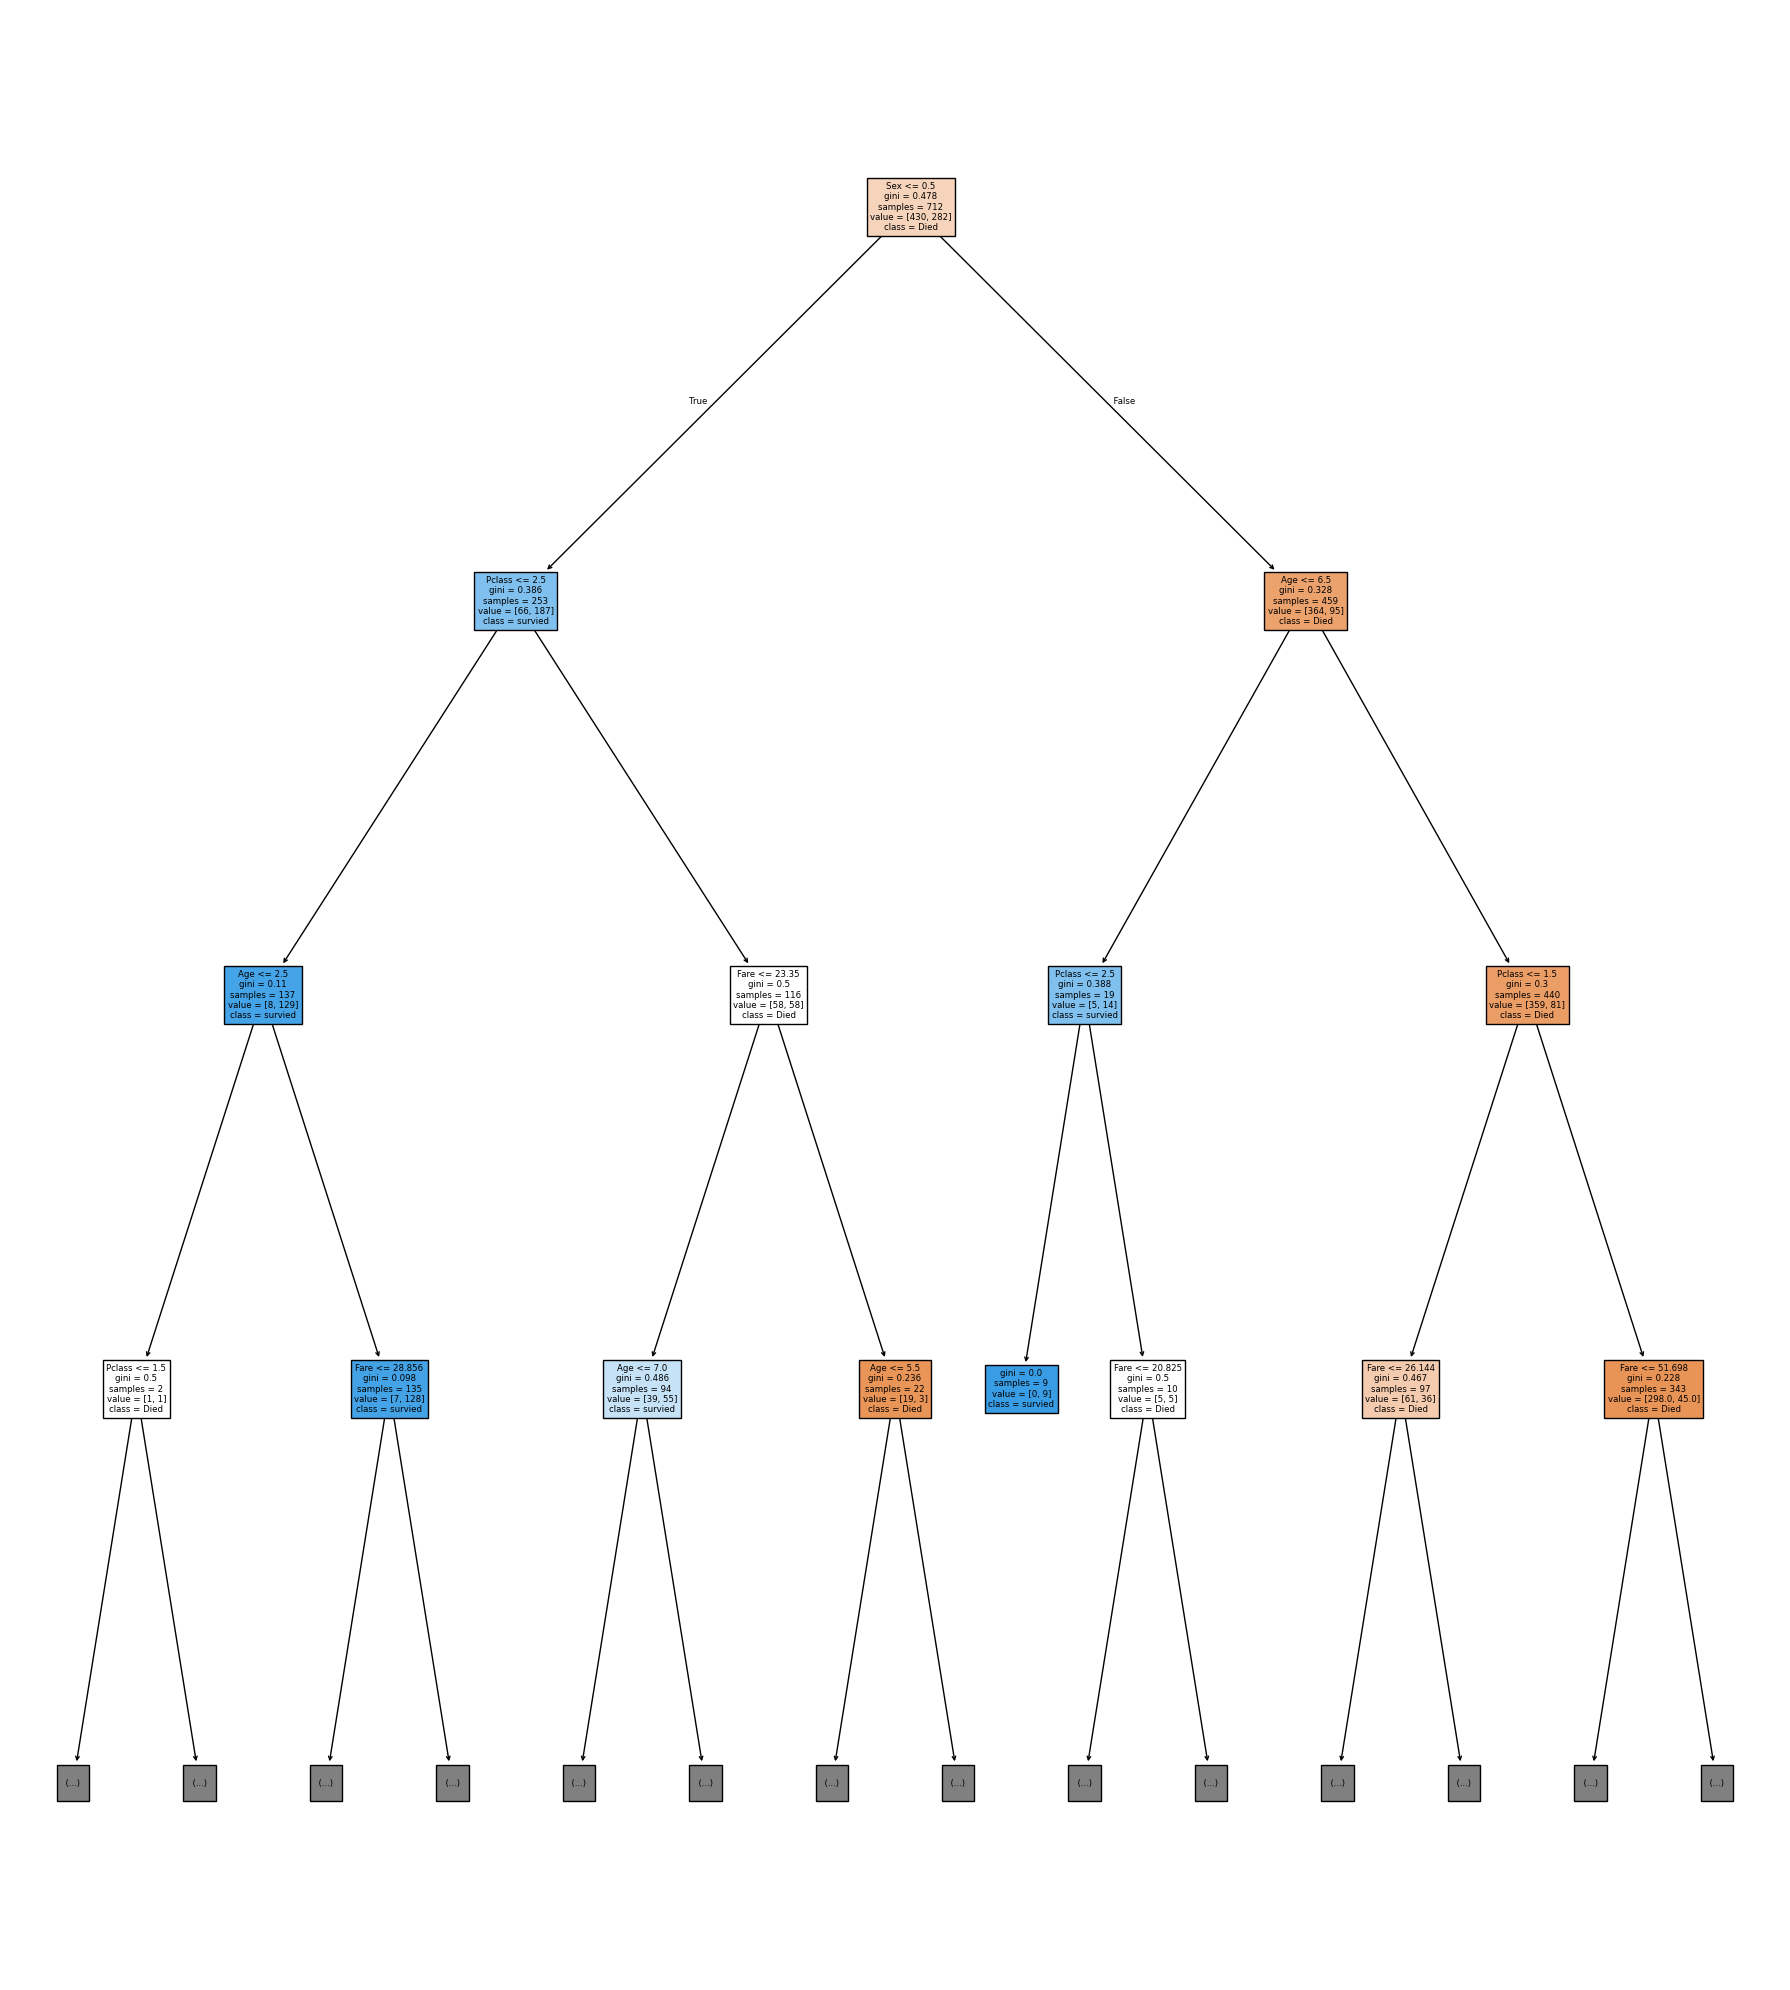

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,20))
plot_tree(
    dtc,
    filled=True,
    feature_names=x.columns,
    class_names=["Died","survied"],
    max_depth =3
          )
plt.tight_layout()
plt.show()

# Decision Tree With Pre-Prunning

Accuracy for max depth 2 is 0.8324022346368715
Accuracy for max depth 4 is 0.8715083798882681
Accuracy for max depth 6 is 0.8547486033519553
Accuracy for max depth 8 is 0.8491620111731844
Accuracy for max depth 10 is 0.8435754189944135
Accuracy for max depth 12 is 0.8268156424581006


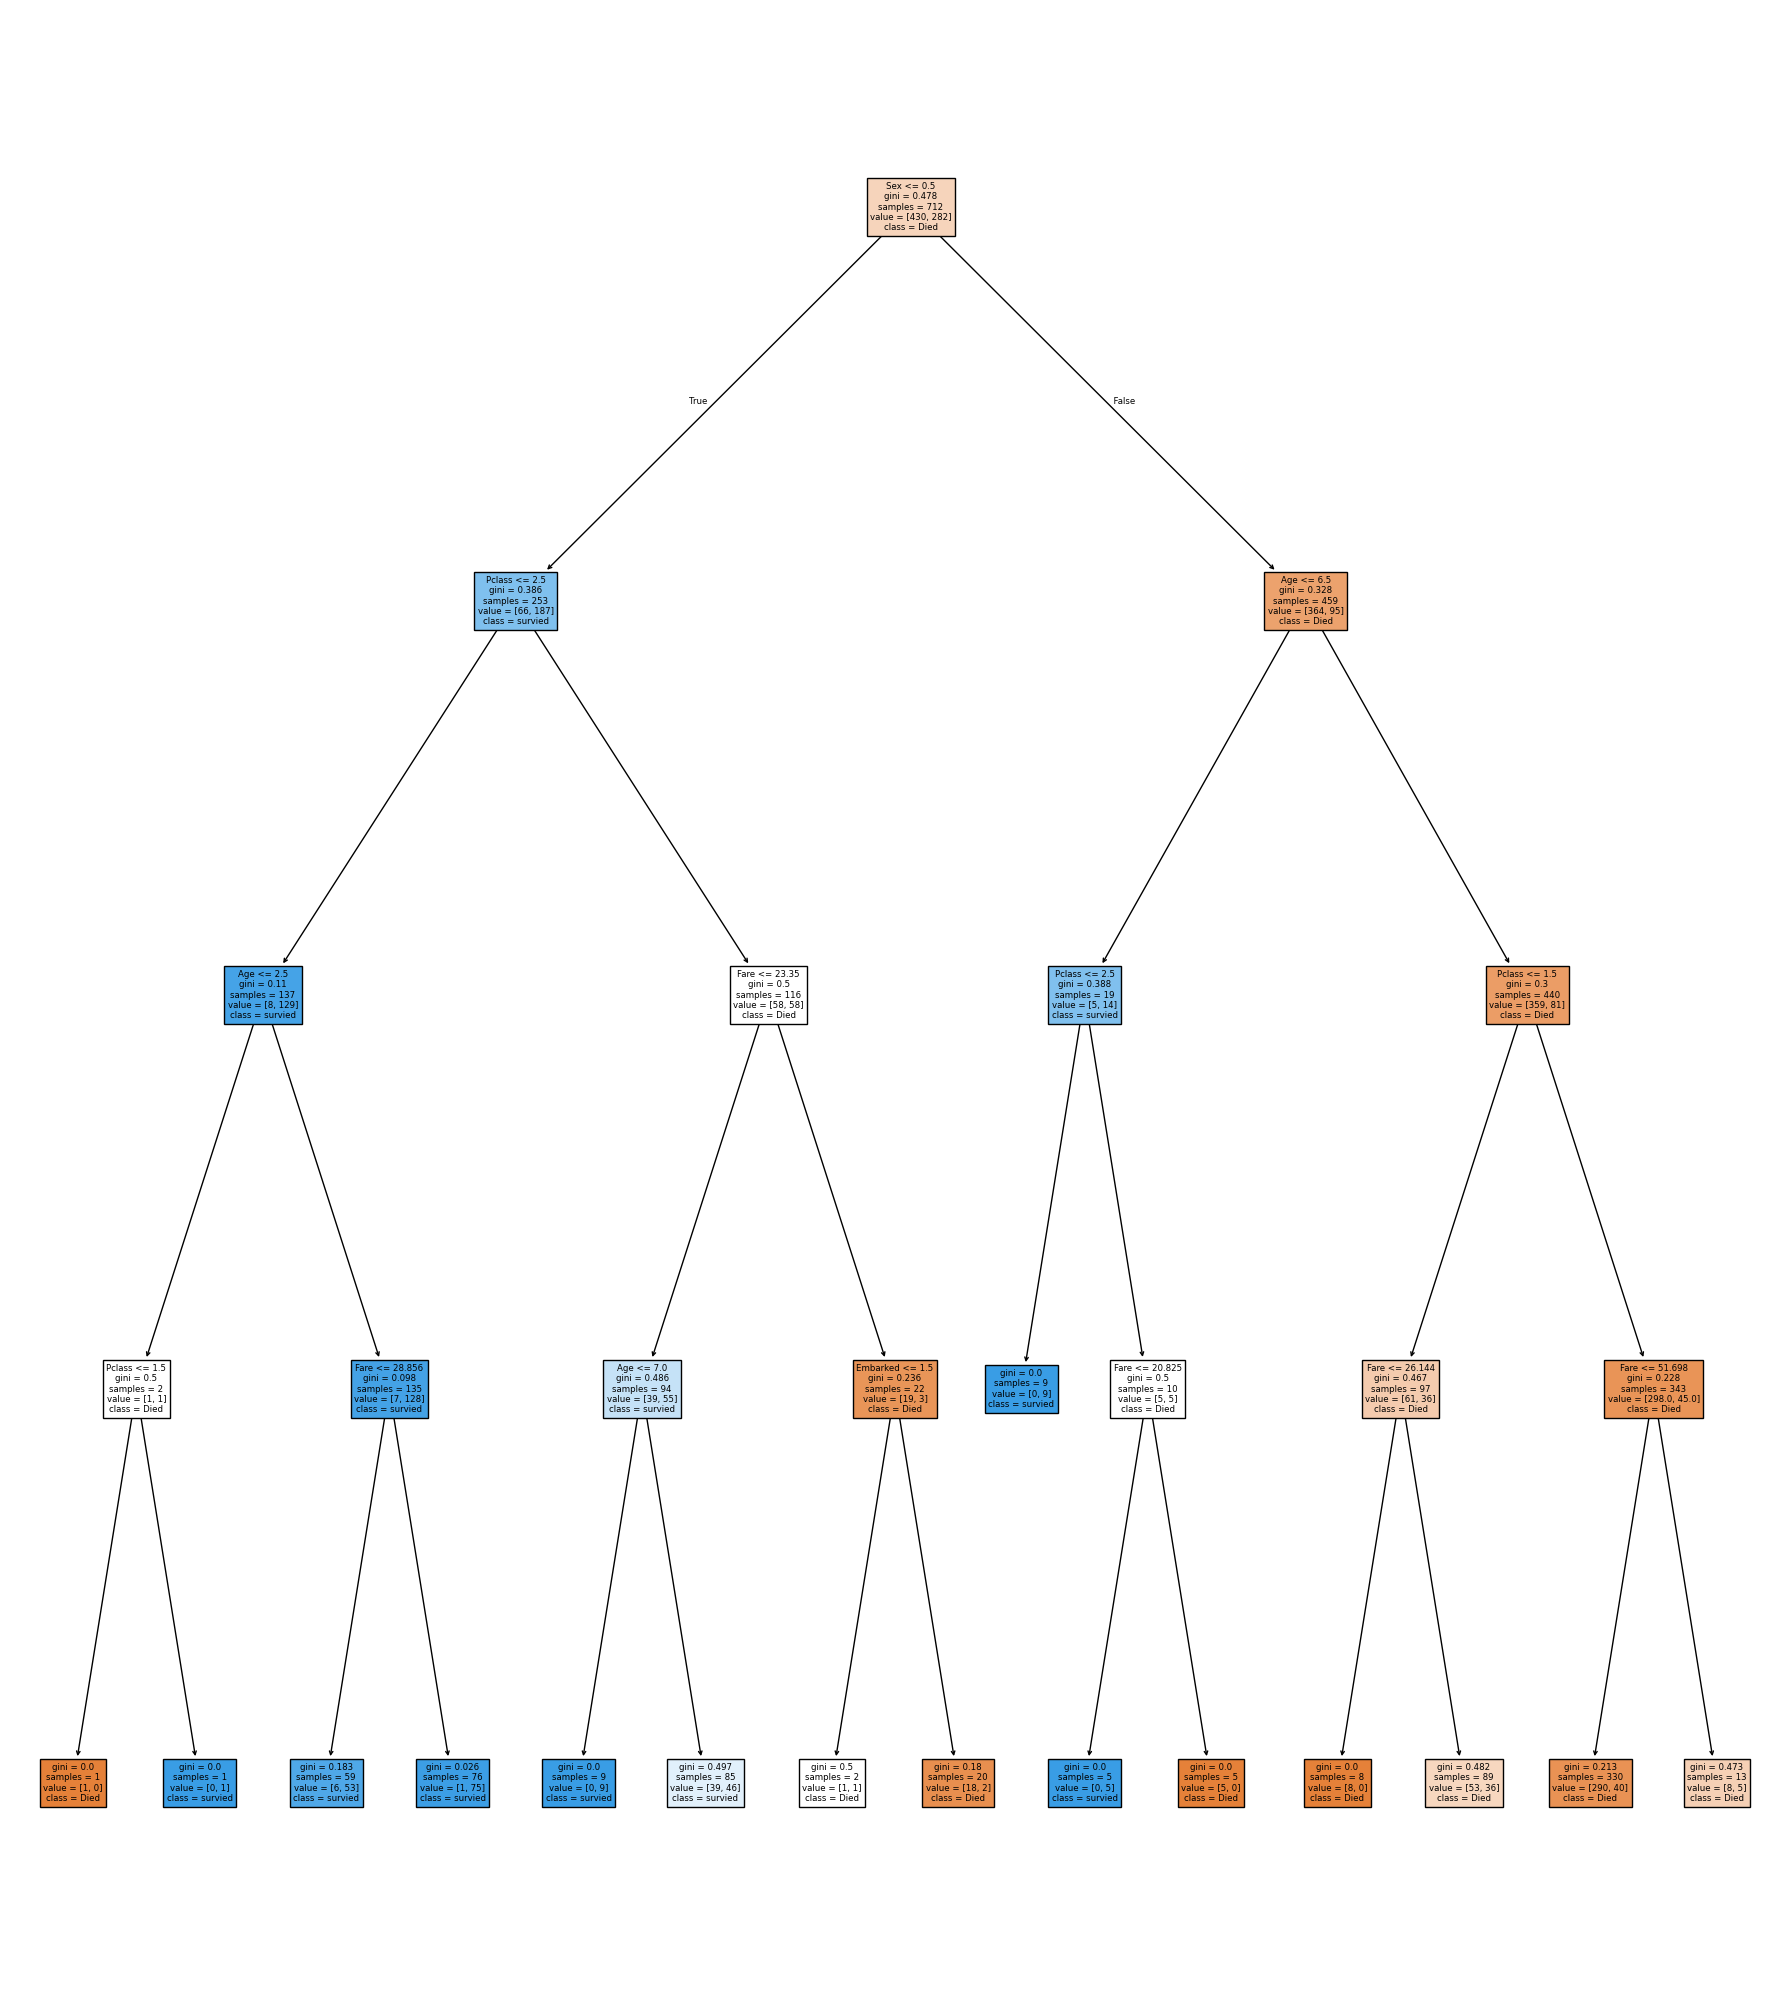

In [ ]:
# Using Max Depth Rule
max_depths =[2,4,6,8,10,12]

for depth in max_depths:
  dtc = DecisionTreeClassifier(max_depth=depth)
  dtc.fit(x_train,y_train)

  acc=dtc.score(x_test,y_test)
  print(f"Accuracy for max depth {depth} is {acc}")

  if depth==4:
    plt.figure(figsize=(18,20))
    plot_tree(
    dtc,
    filled=True,
    feature_names=x.columns,
    class_names=["Died","survied"],

          )
plt.tight_layout()
plt.show()

Accuracy for min sample split 8 is 0.8435754189944135
Accuracy for min sample split 10 is 0.8379888268156425
Accuracy for min sample split 12 is 0.8379888268156425
Accuracy for min sample split 14 is 0.8435754189944135
Accuracy for min sample split 16 is 0.8603351955307262
Accuracy for min sample split 18 is 0.8547486033519553
Accuracy for min sample split 20 is 0.8379888268156425


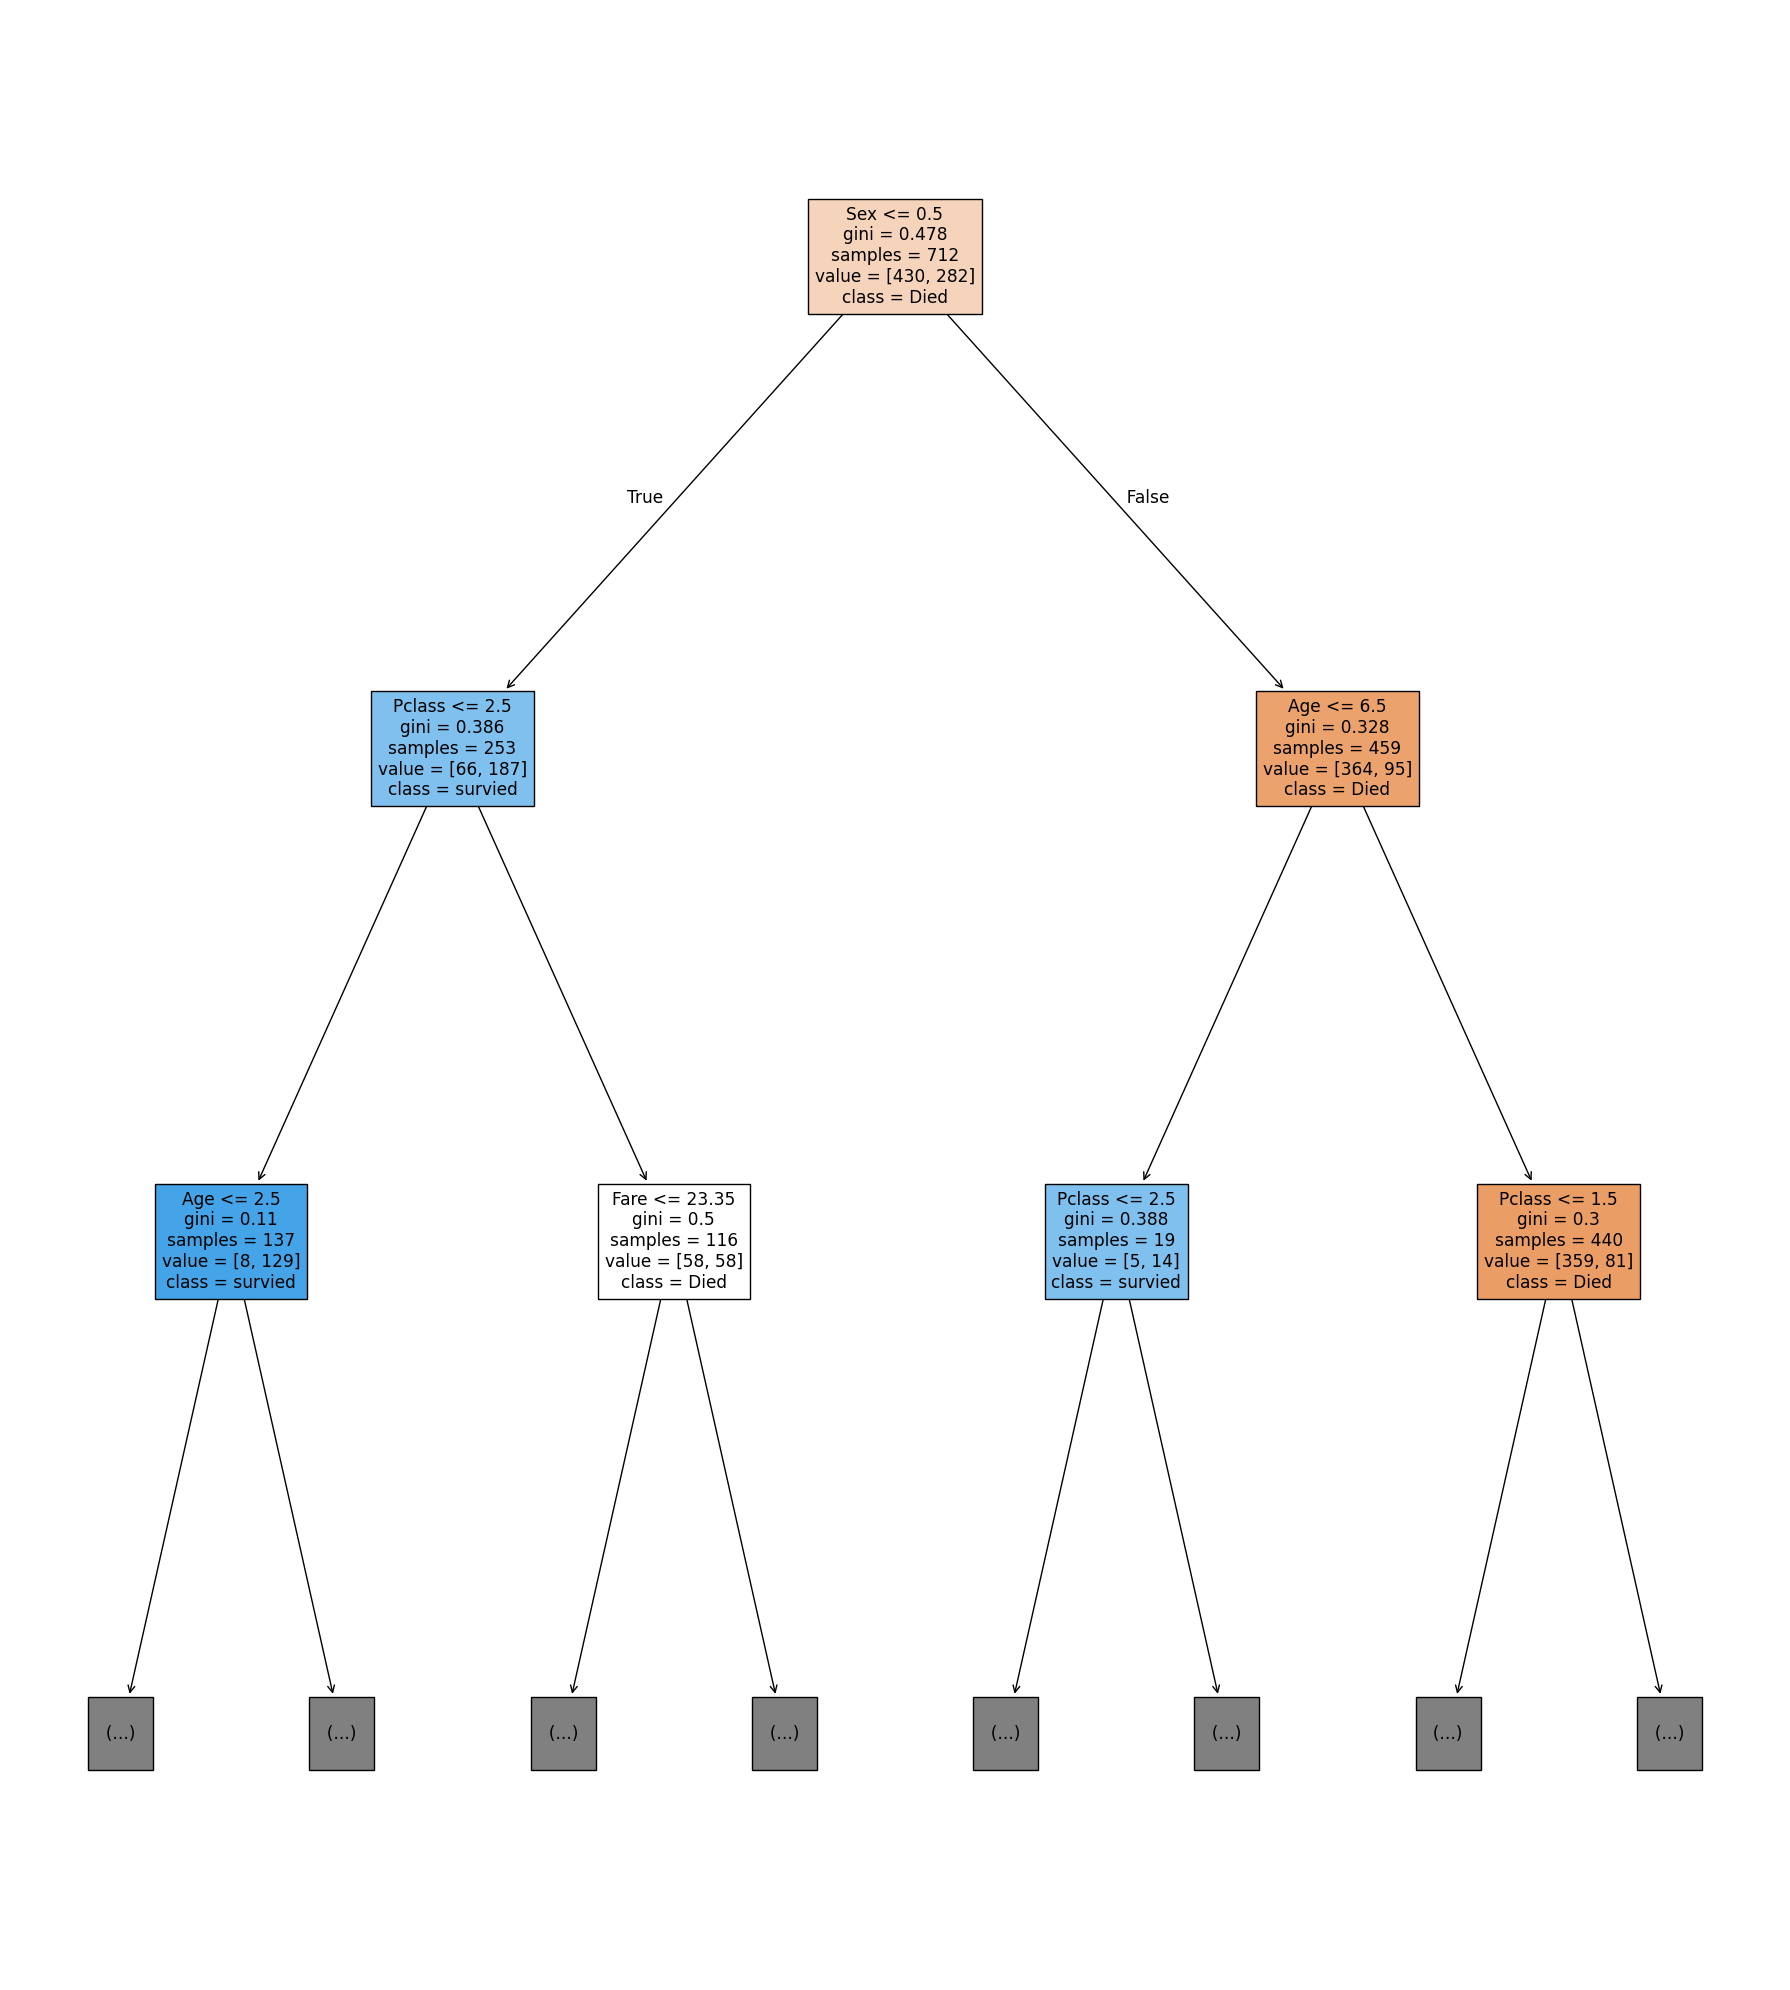

In [ ]:
# Using Min Sample Split Rule
min_samples =[8,10,12,14,16,18,20]

for split in min_samples:
  dtc = DecisionTreeClassifier(min_samples_split=split)
  dtc.fit(x_train,y_train)

  acc=dtc.score(x_test,y_test)
  print(f"Accuracy for min sample split {split} is {acc}")

  if split==16:
    plt.figure(figsize=(18,20))
    plot_tree(
    dtc,
    filled=True,
    feature_names=x.columns,
    class_names=["Died","survied"],
    max_depth=2
          )
plt.tight_layout()
plt.show()
